<a href="https://colab.research.google.com/github/UKD1211/Deep_Learning_Prac_cX/blob/main/Drop_out_classifiaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

In [58]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [59]:
df= df.drop(columns = ['User ID','Gender'])

In [60]:
X = df.drop(columns = ['Purchased'])
y = df['Purchased']

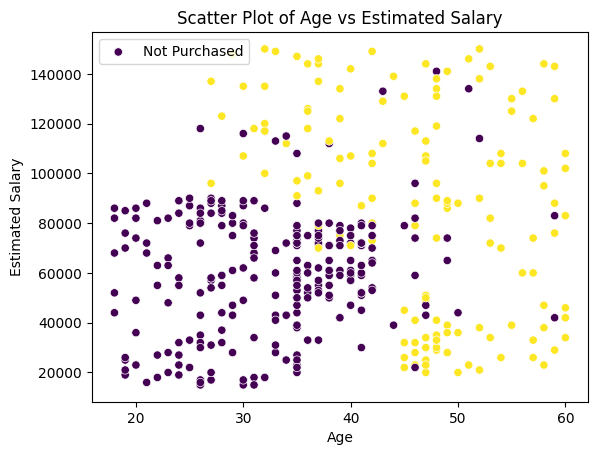

In [61]:
sns.scatterplot(data = df,x = df['Age'], y = df['EstimatedSalary'],c = df['Purchased'])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Scatter Plot of Age vs Estimated Salary")
plt.legend(["Not Purchased","Purchased"])
plt.show()

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [63]:
sc = StandardScaler()
X_train_mod = sc.fit_transform(X_train)
X_test_mod = sc.transform(X_test)

In [64]:
# Without DropOut
model1 = Sequential()

model1.add(Dense(10,activation = "relu",input_dim = 2))
model1.add(Dense(10,activation = "relu"))
model1.add(Dense(5,activation = "relu"))
model1.add(Dense(1,activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
model1.compile(loss = "binary_crossentropy",optimizer = "adam",metrics = ["accuracy"])

In [ ]:
history1 = model1.fit(X_train_mod,y_train, validation_data = (X_test_mod,y_test),epochs = 800)

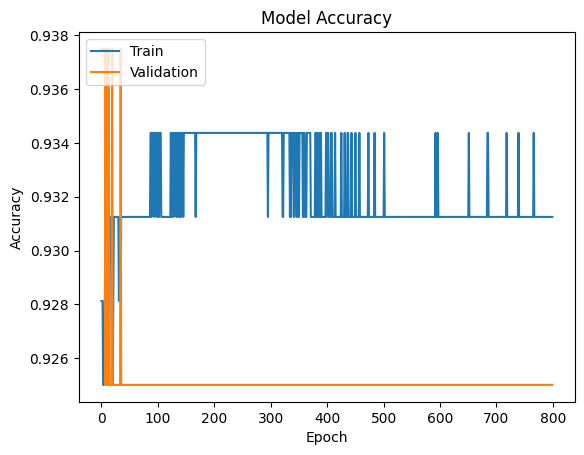

In [69]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

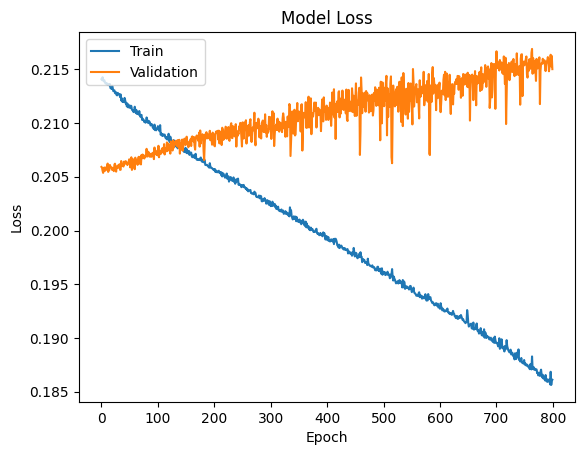

In [70]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [71]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


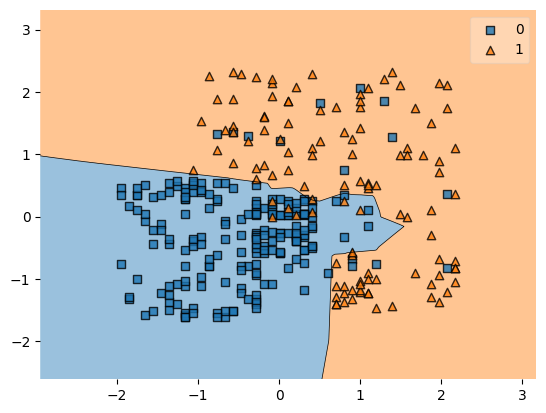

In [72]:
plot_decision_regions(X_train_mod, y_train.values, clf=model1)
plt.show()

In [73]:
#with DropOut

In [77]:
model2 = Sequential()
model2.add(Dense(10,activation = "relu",input_dim = 2))
model2.add(Dropout(0.2))
model2.add(Dense(10,activation = "relu"))
model2.add(Dropout(0.2))
model2.add(Dense(5,activation = "relu"))
model2.add(Dropout(0.2))
model2.add(Dense(1,activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(loss = "binary_crossentropy",optimizer = "adam",metrics = ["accuracy"])
history2 = model2.fit(X_train_mod,y_train, validation_data = (X_test_mod,y_test),epochs = 800)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


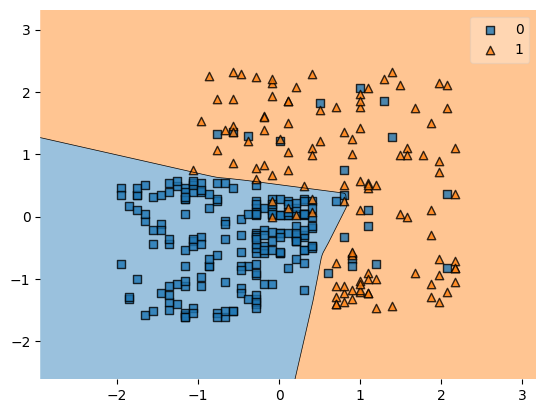

In [80]:
plot_decision_regions(X_train_mod, y_train.values, clf=model2)
plt.show()

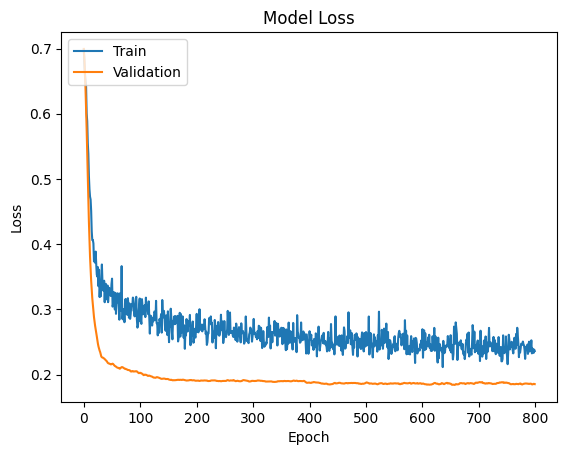

In [81]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model3 = Sequential()
model3.add(Dense(10,activation = "relu",input_dim = 2))
model3.add(Dropout(0.9))
model3.add(Dense(10,activation = "relu"))
model3.add(Dropout(0.9))
model3.add(Dense(5,activation = "relu"))
model3.add(Dropout(0.9))
model3.add(Dense(1,activation = "sigmoid"))
model3.compile(loss = "binary_crossentropy",optimizer = "adam",metrics = ["accuracy"])
history3 = model3.fit(X_train_mod,y_train, validation_data = (X_test_mod,y_test),epochs = 800)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


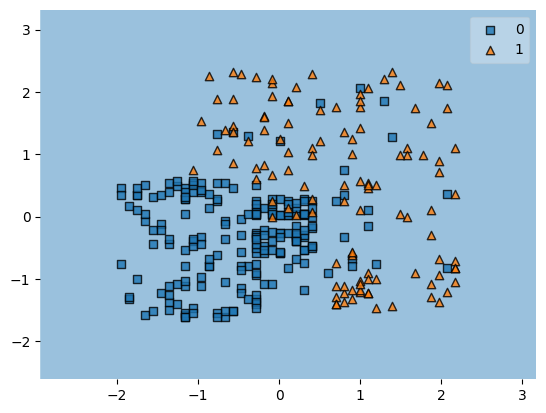

In [83]:
plot_decision_regions(X_train_mod, y_train.values, clf=model3)
plt.show()

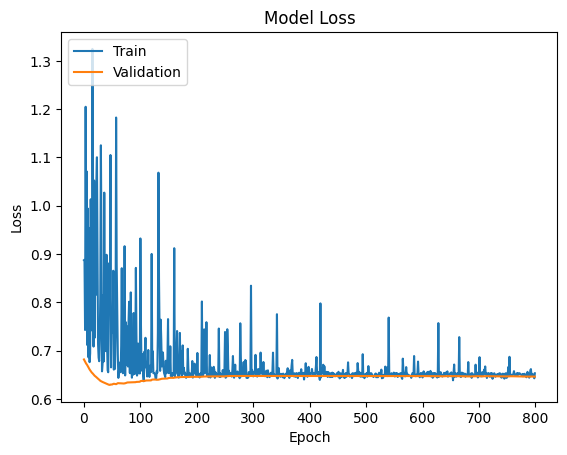

In [85]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

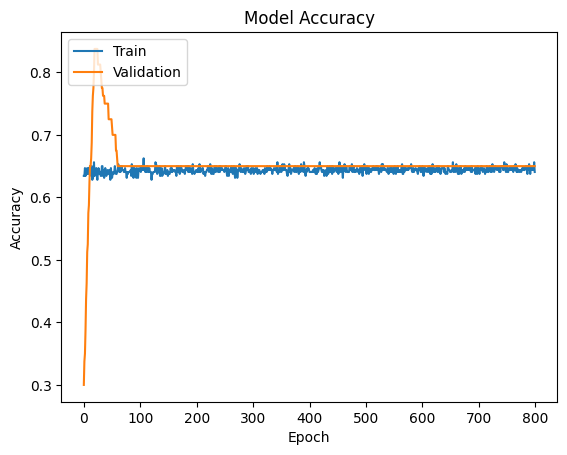

In [86]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()